In [282]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import re

In [283]:
DATA_FOLDER = "./Data/SOM"
START_YEAR = 1980
END_YEAR = 2024

LEVEL = "meso"
TAXONOMY_CSV = "./Data/citation_topics_2024.csv"

FEATURES = [
    ("weights", "WoS Categories"),
    ("weights", "Document Types"),
    ("weights", "Documents,"),
    ("scores",  "Ave. citations"),
    ("scores",  "Ave. authorships"),
    ("scores",  "Ave. references"),
    ("scores",  "Percent of documents"),
    ("scores",  "Percent of documents Int. Coll.")
]


In [284]:
def load_taxonomy_mapping(csv_path: str):
    """
    CSV:
      macro_id,macro_label,meso_id,meso_label,micro_id,micro_label

    Esta función toma la primera parte antes del espacio de la columna micro_label
      ej: tomamos "4.61.1460" de "4.61.1460 Bayesian Networks"
    Y  luego en  base a ese codigo guardamos  la informacion de cada microtopico de forma separada
    """
    df = pd.read_csv(csv_path)

    micro_code = df["micro_label"].astype(str).str.split(" ").str[0].str.strip() #Esta linea  precisammente extrae esos  numeros (la taxonomia que define ese nodo)
    #micro_code es una lista con todos los codigos definidos en el csv

    #Por cada fila del csv mapeamos en  base al micro  code, es un diccionario de diccionarios
    mapping = {}
    for i, code in enumerate(micro_code):
        mapping[code] = {
            "macro_id": int(df.loc[i, "macro_id"]),
            "meso_id":  int(df.loc[i, "meso_id"]),
            "micro_id": int(df.loc[i, "micro_id"]),
            "macro_label": str(df.loc[i, "macro_label"]),
            "meso_label":  str(df.loc[i, "meso_label"]),
            "micro_label": str(df.loc[i, "micro_label"]),
        }
    return mapping


In [285]:
'''
Determina el nodo ego. Su id empieza con 'MCT' o el 'Percent of documents' es igual a 100
Returns: El nodo ego
'''
def is_ego_node(node):
    return str(node.get("id","")).startswith("MCT") or node.get("scores", {}).get("Percent of documents", 0) == 100.0


In [286]:
'''
Calcula toda la información a nivel mesotópico, desde el numero de clusters, el id del ego
y una matriz de dimensión N x 8, con N el numero de alters de la red, y el 8
porque hay 8 features

Dependiendo el nivel (level) se busca la informacion de los alters, por  ejemplo para el nivel meso
se guardará el número asociado a ese mesotopico: en 4.61.1460, se  extrae el 61.
 '''
def parse_microradial(raw_json, taxonomy_map: dict, level: str):

    if level not in ("macro", "meso", "micro"):
        raise ValueError("level debe ser: 'macro', 'meso' o 'micro'")
    items = raw_json["network"]["items"]
    links = raw_json["network"]["links"]

    # Encontrar ego, se añade una pequeña excepcion (Gracias a esto se detectó una anomalia en el año 1990 de los datos de SOM)
    ego_indices = [i for i, n in enumerate(items) if is_ego_node(n)]
    if len(ego_indices) != 1:
        raise ValueError(f"Se esperaría 1 ego, pero encontré {len(ego_indices)}")

    ego_idx = ego_indices[0]
    ego_id = items[ego_idx]["id"]

    # máscara de alters, lo que se hace es crear un array de puros 1's (True) donde el unico 0 (False) es el ego
    alter_mask = np.ones(len(items), dtype=bool)
    alter_mask[ego_idx] = False

    # matriz X de alters (N x 8) N es el numero de alters de la red, 8 features
    X = []
    categories = []
    missing_in_csv = 0
   
    for i, node in enumerate(items):
        if not alter_mask[i]:
            continue
        row = []
        #Scope es la primera identificacion para acceder a los features. Ej: weights o scores
        #Key ya es como tal la propiedad a extraer. Ej: Percent of documents, aver autorship, etc.
        for scope, key in FEATURES:
            row.append(node.get(scope, {}).get(key, 0))
        X.append(row)

        code = str(node.get("id")) # ej "4.61.1460"
        info = taxonomy_map.get(code)

        if info is None: #-1 por si no se encontró
            categories.append(-1) 
            missing_in_csv += 1
        else:
            categories.append(int(info[f"{level}_id"]))

    #Simplemente los pasamos a arreglos de numpy para poderlos manipular facilmente
    X = np.asarray(X, dtype=float)
    categories = np.asarray(categories, dtype=int)

    return {
        "ego_id": ego_id,
        "X_alters": X,
        "categories_alters": categories,
        "n_items_total": len(items),
        "n_links_total": len(links),
        "missing_in_csv": missing_in_csv
    }


In [287]:
def validate_snapshot(parsed, year):
    warnings = {}

    X = parsed["X_alters"]
    if X.ndim != 2:
        raise ValueError(f"[{year}] X_alters no es 2D (shape={X.shape}).")
    if X.shape[1] != len(FEATURES):
        raise ValueError(f"[{year}] X_alters tiene {X.shape[1]} features, esperaba {len(FEATURES)}.")
    if X.shape[0] == 0:
        raise ValueError(f"[{year}] No hay alters (X_alters vacío).")

    #isnan y isinf crean una mascara del tamaño de la matriz X para detectar nans o infs
    #Si hay alguno se reporta
    nan_count = int(np.isnan(X).sum())
    inf_count = int(np.isinf(X).sum())

    if nan_count > 0 or inf_count > 0:
        warnings["nan_inf"] = {"nan": nan_count, "inf": inf_count}

    if parsed.get("missing_in_csv", 0) > 0:
        warnings["missing_in_csv"] = parsed["missing_in_csv"]

    return warnings

In [288]:
def build_yearly_index(data_folder, start_year, end_year,  taxonomy_map, level):
    """
    Construye los snapshots de cada año (diccionario) con la información definida, esto
    se  hace dependiendo el nivel con el que se trabaja.

    Para cada año:
    - Carga el JSON de la red.
    - Lo procesa a nivel taxonómico (macro/meso/micro) usando parse_microradial.
    - Genera métricas resumen (n_alters, n_categories, missing, etc).
    - Captura errores y warnings

    Devuelve:
      - snapshots: dict[year] ->  snapshot procesado
      - df_index: DataFrame con resumen anual
      - df_issues: DataFrame con errores/warnings por año
    """
    print("Nivel taxonómico: ", level)

    snapshots = {}
    index_rows = []
    issue_rows = []

    for year in range(start_year, end_year + 1):
        file_path = os.path.join(data_folder, f"network_{year}.json")

        if not os.path.exists(file_path):
            issue_rows.append({
                "year": year,
                "type": "missing_file",
                "detail": f"Archivo no encontrado: {file_path}"
            })
            continue

        try:
            with open(file_path, "r", encoding="utf-8") as f:
                raw_json = json.load(f)

            parsed = parse_microradial(raw_json, taxonomy_map=taxonomy_map, level=level)
            warnings = validate_snapshot(parsed, year)


            snapshots[year] = parsed

            # Resumen anual
            X = parsed["X_alters"]
            cats = parsed["categories_alters"]

            # quitar -1 (no mapeados) para contar categorías válidas
            cats_valid = cats[cats >= 0]
            index_rows.append({
                "year": year,
                "ego_id": parsed["ego_id"],
                "n_items_total": parsed["n_items_total"],
                "n_links_total": parsed["n_links_total"],
                "n_alters": int(X.shape[0]),
                "n_features": int(X.shape[1]),
                "n_categories_unique": int(len(set(cats_valid.tolist()))),
                "missing_in_csv": int(parsed.get("missing_in_csv", 0)),
                "level_used": level
            })

            # Guardar warnings si existen
            if warnings:
                issue_rows.append({
                    "year": year,
                    "type": "warning",
                    "detail": json.dumps(warnings, ensure_ascii=False)
                })

            
            print(f"[OK] {year} | alters={X.shape[0]} | cats_unique={len(set(cats_valid.tolist()))} | missing_csv={parsed.get('missing_in_csv',0)}")

        except Exception as e:
            issue_rows.append({
                "year": year,
                "type": "error",
                "detail": str(e)
            })
            print(f"[ERROR] {year}: {e}")

    df_index = pd.DataFrame(index_rows).sort_values("year").reset_index(drop=True)
    df_issues = pd.DataFrame(issue_rows, columns=["year", "type", "detail"])
    if not df_issues.empty:
        df_issues = df_issues.sort_values(["year", "type"]).reset_index(drop=True)

    return snapshots, df_index, df_issues



In [289]:

taxonomy_map = load_taxonomy_mapping(TAXONOMY_CSV)
snapshots, df_index, df_issues = build_yearly_index(
    data_folder=DATA_FOLDER,
    start_year=START_YEAR,
    end_year=END_YEAR,
    taxonomy_map=taxonomy_map,
    level=LEVEL
)

Nivel taxonómico:  meso
[OK] 1980 | alters=26 | cats_unique=19 | missing_csv=0
[OK] 1981 | alters=63 | cats_unique=39 | missing_csv=0
[OK] 1982 | alters=58 | cats_unique=34 | missing_csv=0
[OK] 1983 | alters=35 | cats_unique=27 | missing_csv=0
[OK] 1984 | alters=45 | cats_unique=28 | missing_csv=0
[OK] 1985 | alters=33 | cats_unique=25 | missing_csv=0
[OK] 1986 | alters=18 | cats_unique=14 | missing_csv=0
[OK] 1987 | alters=286 | cats_unique=127 | missing_csv=0
[OK] 1988 | alters=128 | cats_unique=67 | missing_csv=0
[OK] 1989 | alters=61 | cats_unique=35 | missing_csv=0
[ERROR] 1990: Se esperaría 1 ego, pero encontré 2
[OK] 1991 | alters=244 | cats_unique=107 | missing_csv=0
[OK] 1992 | alters=224 | cats_unique=114 | missing_csv=0
[OK] 1993 | alters=103 | cats_unique=55 | missing_csv=0
[OK] 1994 | alters=63 | cats_unique=41 | missing_csv=0
[OK] 1995 | alters=167 | cats_unique=91 | missing_csv=0
[OK] 1996 | alters=595 | cats_unique=210 | missing_csv=0
[OK] 1997 | alters=150 | cats_uniqu

In [290]:
print("\n--- Resumen (df_index) ---")
print(df_index)

print("\n--- Issues/Warns (df_issues) ---")
print(df_issues.head())

print(f"\nAños procesados correctamente: {len(snapshots)} / {END_YEAR - START_YEAR + 1}")


--- Resumen (df_index) ---
    year         ego_id  n_items_total  n_links_total  n_alters  n_features  \
0   1980  MCT.4.61.1335             27             26        26           8   
1   1981  MCT.4.61.1335             64             63        63           8   
2   1982  MCT.4.61.1335             59             58        58           8   
3   1983  MCT.4.61.1335             36             35        35           8   
4   1984  MCT.4.61.1335             46             45        45           8   
5   1985  MCT.4.61.1335             34             33        33           8   
6   1986  MCT.4.61.1335             19             18        18           8   
7   1987  MCT.4.61.1335            287            286       286           8   
8   1988  MCT.4.61.1335            129            128       128           8   
9   1989  MCT.4.61.1335             62             61        61           8   
10  1991  MCT.4.61.1335            245            244       244           8   
11  1992  MCT.4.61.1335 

In [291]:
def safe_probs(masses: np.ndarray):
    """
    Convierte masas >=0 en distribución p_i.
    Regresa None si no se puede (suma 0 o NaN).
    Prepara los datos para ser usados en las formulas de diversidad: shanon, simpson, etc.
    """
    #Las masaas son la cantidad de algo, por ejemplo el numero de documentos
    masses = np.asarray(masses, dtype=float)
    masses = np.where(np.isfinite(masses), masses, 0.0)
    masses = np.where(masses < 0, 0.0, masses)

    total = masses.sum()
    if total <= 0:
        return None
    return masses / total #Se devuelve la distribucion, EJ: [20,30,50] entonces regresa: [0.2,0.3,0.5]

In [292]:
#Algo importante a considerar es qued hill necesita una distribucion p que sume 1
#Es importante el cómo es que yo defino esto, en mi caso de momento es con "Documents,"
#Hill numbers requiere categorias. DE MOMENTO (porque aun no estoy seguro) uso a los clusters. 
#De lo contrario, ¿cuáles serían las categorias?, aparte, mis nodos unicamente cuentan con un solo valor categorico: numero de cluster.

#La distribucion es en base a una masa, features como ave references, o ave citations no convienen porque son promedios.
def hill_numbers(p: np.ndarray):
    """
    Calcula Hill numbers para q=0,1,2.
    p debe ser distribución (suma 1).
    Devuelve (D0, D1, D2).
    """
    if p is None:
        return (np.nan, np.nan, np.nan)

    p = np.asarray(p, dtype=float)
    p = p[p > 0]  # evitar log(0), pues no está definido
    if p.size == 0:
        return (np.nan, np.nan, np.nan)

    # q=0: riqueza (número de categorías con masa >0)
    D0 = float(p.size)

    # q=1: exp(Shannon)
    H = -float(np.sum(p * np.log(p)))
    D1 = float(np.exp(H))

    # q=2: inverso de Simpson
    D2 = float(1.0 / np.sum(p ** 2))

    return (D0, D1, D2)

In [293]:
def group_masses_by_category(categories: np.ndarray, masses: np.ndarray):
    """
    Agrupa y suma las masas según su categoria (macro,  meso,  micro).
    Suma la aportacion individual de cada ego a la categoría a la que pertenece
    Regresa: cat,mass : cantidad de categorias únicas y la suma total de masa por cada una
    """
    categories = np.asarray(categories, dtype=int)
    masses = np.asarray(masses, dtype=float)

    # limpiar masas
    masses = np.where(np.isfinite(masses), masses, 0.0)
    masses = np.where(masses < 0, 0.0, masses)

    df = pd.DataFrame({"cat": categories, "mass": masses}) #Simplemente se hace dataframe para poder hacer operaciones sql
    df = df[df["cat"] >= 0] # excluir -1 (no mapeados), es un "por si acaso"
    grp = df.groupby("cat", as_index=False)["mass"].sum().sort_values("cat") #Agrupa todos los que pertenecen al mismo cluster, y suma las masas de los integrantes, al final los odena
    return grp["cat"].to_numpy(), grp["mass"].to_numpy()


In [294]:
def meso_stats_from_X(X: np.ndarray):
    """
    Calcula centro y dispersión de una nube de puntos (alters x features).
    Regresa dict con métricas globales + arrays de mean/var por feature.
    """
    X = np.asarray(X, dtype=float) #Pasar a arreglo de numpy
    X = np.where(np.isfinite(X), X, np.nan) #Limpieza de datos: donde haya nan, o infinito se reemplaza por la media
    mu = np.nanmean(X, axis=0) #Media de cada columna (cada)
    var = np.nanvar(X, axis=0) # var por feature 

    # cov y trace (si N>=2)
    if X.shape[0] >= 2:
        # para cov: reemplazar NaN por mean de columna para no romper el calculo, es una estrategia clasicca de estadistica
        X_filled = np.where(np.isnan(X), mu, X)
        cov = np.cov(X_filled, rowvar=False)
        trace_cov = float(np.trace(cov))
    else:
        trace_cov = np.nan

    # distancia promedio al centro
    X_filled = np.where(np.isnan(X), mu, X)
    dists = np.linalg.norm(X_filled - mu, axis=1) #linalg es la distancia enlinea recta al alter con respecto a la  media, asis=1 hace que se haga por cada fila
    mean_dist = float(np.mean(dists))
    median_dist = float(np.median(dists))

    return {
        "mu": mu,
        "var": var,
        "trace_cov": trace_cov,
        "mean_dist_to_mu": mean_dist,
        "median_dist_to_mu": median_dist,
    }


In [295]:

def run_stage2(snapshots: dict, feature_names: list, documents_col_name="Documents,"):
    """
    Construye un DataFrame con métricas mesotópicas por año:
    - mean_* por feature
    - var_* por feature
    - trace_cov, mean_dist_to_mu, median_dist_to_mu
    - Hill numbers por categoría con masa Documents

    documents_col_name lo dejo como "Documents,"
    """
    # ubicar índice de la columna Documents,
    # feature_names debe corresponder a FEATURES en el mismo orden
    if documents_col_name not in feature_names:
        print(f"[AVISO] '{documents_col_name}' no está en feature_names. Hill por Documents saldrá NaN.")
        documents_idx = None
    else:
        documents_idx = feature_names.index(documents_col_name)

    rows = [] #aqui se guardaran diccionarios: una fila por año

    for year in sorted(snapshots.keys()):
        snap = snapshots[year]
        X = snap["X_alters"]
        cats = snap["categories_alters"]
       # strengths = snap["strengths_to_ego"]

        stats = meso_stats_from_X(X)
        mu = stats["mu"]
        var = stats["var"]

        row = {
            "year": year,
            "ego_id": snap["ego_id"],
            "n_alters": int(X.shape[0]),
            "missing_in_csv": int(snap.get("missing_in_csv", 0)),
            "trace_cov": stats["trace_cov"],
            "mean_dist_to_mu": stats["mean_dist_to_mu"],
            "median_dist_to_mu": stats["median_dist_to_mu"],
        }

        # mean_* y var_* por feature
        for j, fname in enumerate(feature_names):
            row[f"mean_{fname}"] = float(mu[j]) if np.isfinite(mu[j]) else np.nan
            row[f"var_{fname}"] = float(var[j]) if np.isfinite(var[j]) else np.nan

        # Hill por categorías CSV (macro/meso/micro) usando masa Documents
        if documents_idx is not None:
            docs = X[:, documents_idx]
            _, mass_by_cat = group_masses_by_category(cats, docs)
            p = safe_probs(mass_by_cat)
            D0, D1, D2 = hill_numbers(p)
            row["hill_q0"] = D0
            row["hill_q1"] = D1
            row["hill_q2"] = D2
            row["top1_share"] = float(np.max(p)) if p is not None else np.nan
        else:
            row["hill_q0"] = row["hill_q1"] = row["hill_q2"] = np.nan
            row["top1_share"] = np.nan

        rows.append(row)

    df_stage2 = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
    return df_stage2


In [296]:
feature_names = [k for (_, k) in FEATURES]
df_stage2 = run_stage2(
    snapshots=snapshots,
    feature_names=feature_names,
    documents_col_name="Documents,"
)
out_path = f"./Output/metricas_{LEVEL}.csv"
df_stage2.to_csv(out_path, index=False)
print(f"\n[OK] Guardado: {out_path}")



[OK] Guardado: ./Output/metricas_meso.csv


In [297]:
df = df_stage2.copy()

# Helper: normalización 0-1 (para comparar tendencias)
def minmax_01(series: pd.Series):
    x = series.astype(float).to_numpy()
    mask = np.isfinite(x)
    if mask.sum() == 0:
        return pd.Series([np.nan]*len(series), index=series.index)
    xmin, xmax = np.nanmin(x[mask]), np.nanmax(x[mask])
    if np.isclose(xmin, xmax):
        return pd.Series([0.0]*len(series), index=series.index)
    y = (x - xmin) / (xmax - xmin)
    return pd.Series(y, index=series.index)

# Series temporales

def plot_timeseries_matplotlib(df, cols, title):
    plt.figure(figsize=(12, 6))
    plotted_any = False
    for c in cols:
        if c not in df.columns:
            print(f"[WARN] Columna no encontrada: {c}")
            continue
        plt.plot(df["year"], df[c], marker="o", label=c)
        plotted_any = True

    plt.title(title)
    plt.xlabel("Año")
    plt.ylabel("Valor")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


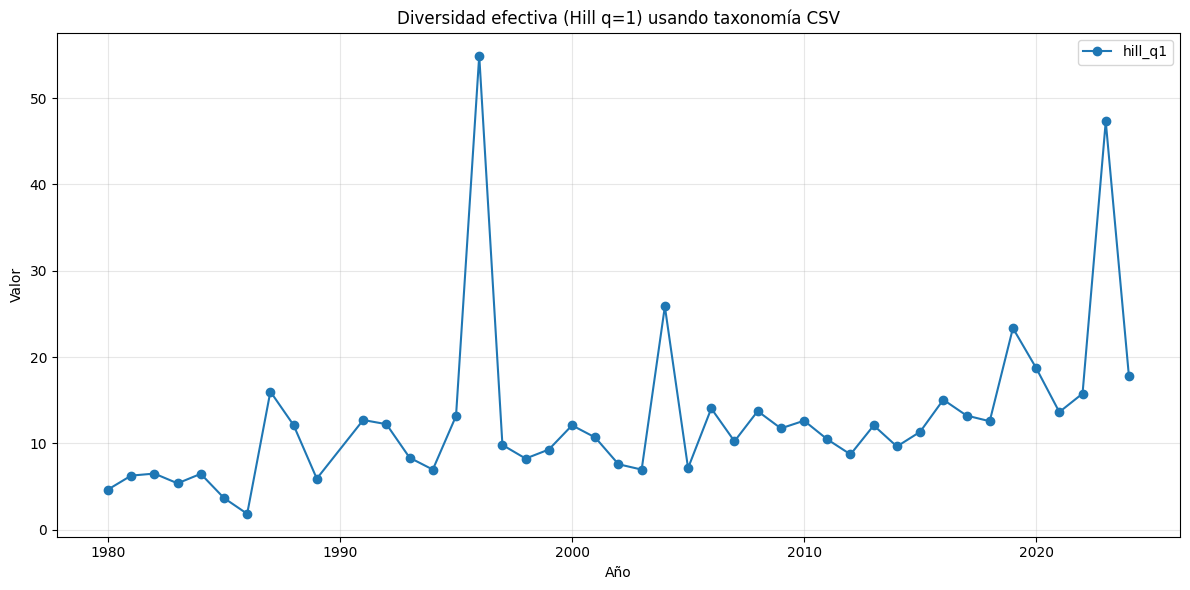

In [298]:
# Series: diversidad efectiva (q=1)
plot_timeseries_matplotlib(
    df,
    cols=["hill_q1"],
    title="Diversidad efectiva (Hill q=1) usando taxonomía CSV"
)


#Sobre clusters:
#“¿Cuántos grupos hay en el vecindario del ego este año?”
#“¿Está dominado por un solo grupo o está balanceado?”

#En la siguiente gráfica un pico alto significa que la masa (en este caso documentos) está más repartida entre varios clusters
#Un pico bajo significa que la masa está concentrada en pocos clusters.
#en 1996 la masa es mas diversa, la mayor concentracion está en unos 5 clusters
# en 1980 la masa está mas condensada en 2 clusters

In [299]:
def plot_separated_metrics(df):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Arriba: Riqueza (q=0)
    if "hill_q0" in df.columns:
        ax1.plot(df["year"], df["hill_q0"], marker="o", label="Categorías presentes (q=0)")
    else:
        ax1.text(0.5, 0.5, "Falta hill_q0", transform=ax1.transAxes, ha="center")
    ax1.set_ylabel("Cantidad de categorías")
    ax1.set_title("Cobertura / riqueza (Hill q=0)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Abajo: Dominancia
    if "top1_share" in df.columns:
        ax2.plot(df["year"], df["top1_share"], marker="s", label="Dominancia (Top 1 Share)")
        ax2.set_ylim(0, 1.1)
    else:
        ax2.text(0.5, 0.5, "Falta top1_share", transform=ax2.transAxes, ha="center")
    ax2.set_ylabel("Proporción del líder (0-1)")
    ax2.set_title("Dominancia: ¿qué tan acaparado está el sistema?")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlabel("Año")

    plt.tight_layout()
    plt.show()



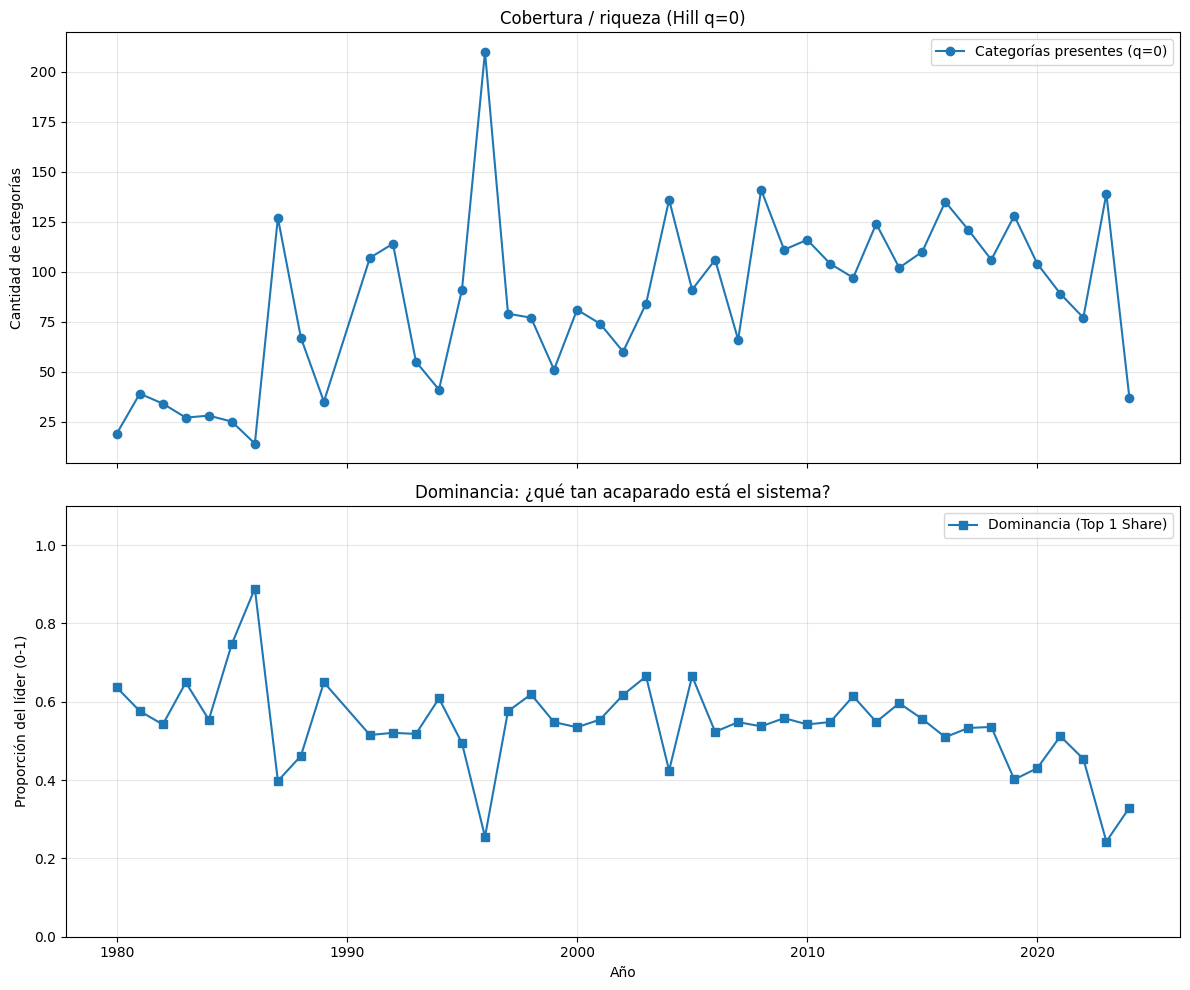

In [300]:
plot_separated_metrics(df)
#EL top 1 share (masa) indica qué proporcion de la masa total está acaparada por el cluster más grande.
#Ej: si el valor es 0.90, entonces el 90% de la producción proviene de un único cluster

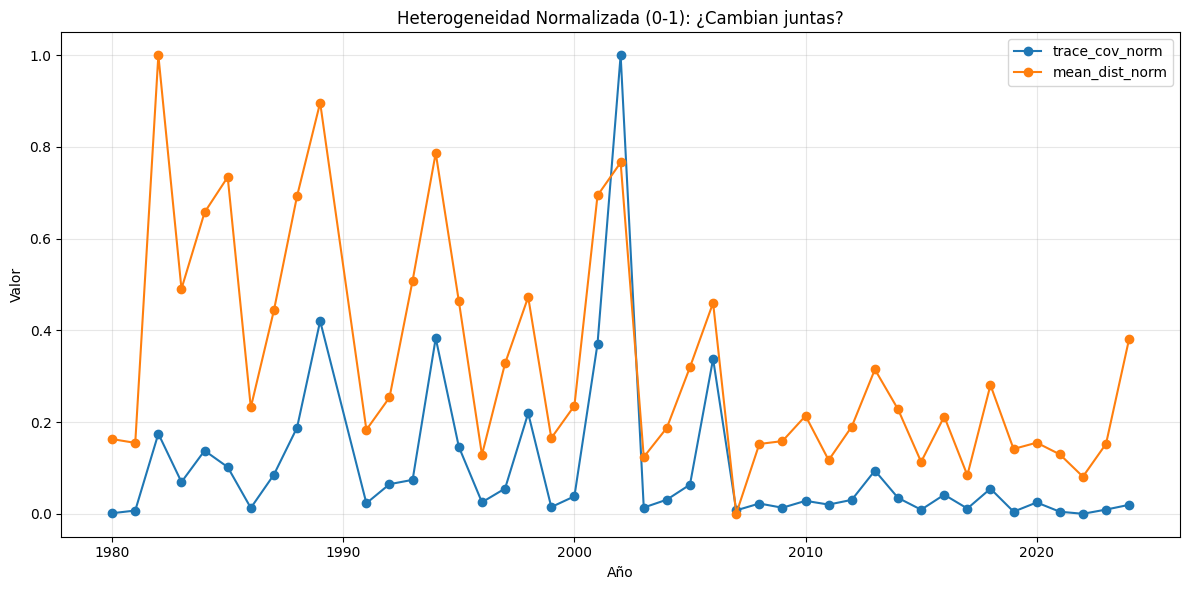

In [301]:
# Aplicamos la normalización (minmax) para que ambas vivan entre 0 y 1
df_norm = df.copy()
df_norm["trace_cov_norm"] = minmax_01(df["trace_cov"])
df_norm["mean_dist_norm"] = minmax_01(df["mean_dist_to_mu"])

plot_timeseries_matplotlib(
    df_norm,
    cols=["trace_cov_norm", "mean_dist_norm"],
    title="Heterogeneidad Normalizada (0-1): ¿Cambian juntas?"
)

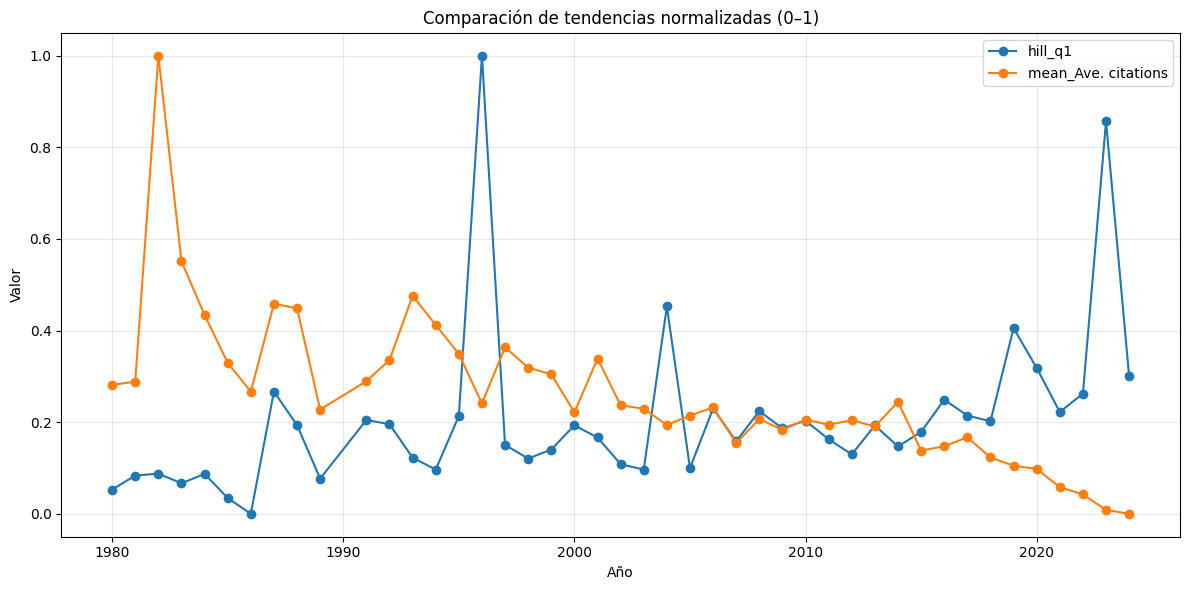

In [302]:
df_cmp = pd.DataFrame({"year": df["year"]})
to_compare = [
    "hill_q1",
   # "hill_strength_q1",
   # "mean_Ave. authorships",
    "mean_Ave. citations",
   # "top1_share_docs"
]

for c in to_compare:
    if c in df.columns:
        df_cmp[c] = minmax_01(df[c])

plot_timeseries_matplotlib(
    df_cmp,
    cols=[c for c in to_compare if c in df_cmp.columns],
    title="Comparación de tendencias normalizadas (0–1)"
)

#"Cuando el ego diversifica sus temas, tiende a colaborar con gente de mayor impacto" (hill vs documents)

In [303]:
# Correlacion de pearson
metrics_core = [
    "hill_q1", "hill_q2",
    "top1_share",
    "trace_cov", "mean_dist_to_mu",
    "mean_Ave. authorships", "mean_Ave. citations", "mean_Ave. references",
    "mean_Percent of documents", "mean_Percent of documents Int. Coll."
]

metrics_core = [c for c in metrics_core if c in df.columns]

df_metrics = df[metrics_core].copy()

corr_pearson = df_metrics.corr(method="pearson")
corr_spearman = df_metrics.corr(method="spearman")

print("\n--- Correlación Pearson (métricas core) ---")
print(corr_pearson.round(3))

print("\n--- Correlación Spearman (métricas core) ---")
print(corr_spearman.round(3))


--- Correlación Pearson (métricas core) ---
                                      hill_q1  hill_q2  top1_share  trace_cov  \
hill_q1                                 1.000    0.963      -0.827     -0.200   
hill_q2                                 0.963    1.000      -0.856     -0.186   
top1_share                             -0.827   -0.856       1.000      0.188   
trace_cov                              -0.200   -0.186       0.188      1.000   
mean_dist_to_mu                        -0.330   -0.233       0.232      0.690   
mean_Ave. authorships                   0.514    0.477      -0.564     -0.297   
mean_Ave. citations                    -0.352   -0.290       0.253      0.213   
mean_Ave. references                   -0.078    0.026      -0.057      0.547   
mean_Percent of documents              -0.450   -0.359       0.636      0.036   
mean_Percent of documents Int. Coll.    0.342    0.370      -0.346     -0.339   

                                      mean_dist_to_mu  mean_Ave

In [304]:
def plot_corr_matrix(corr, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(corr.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()

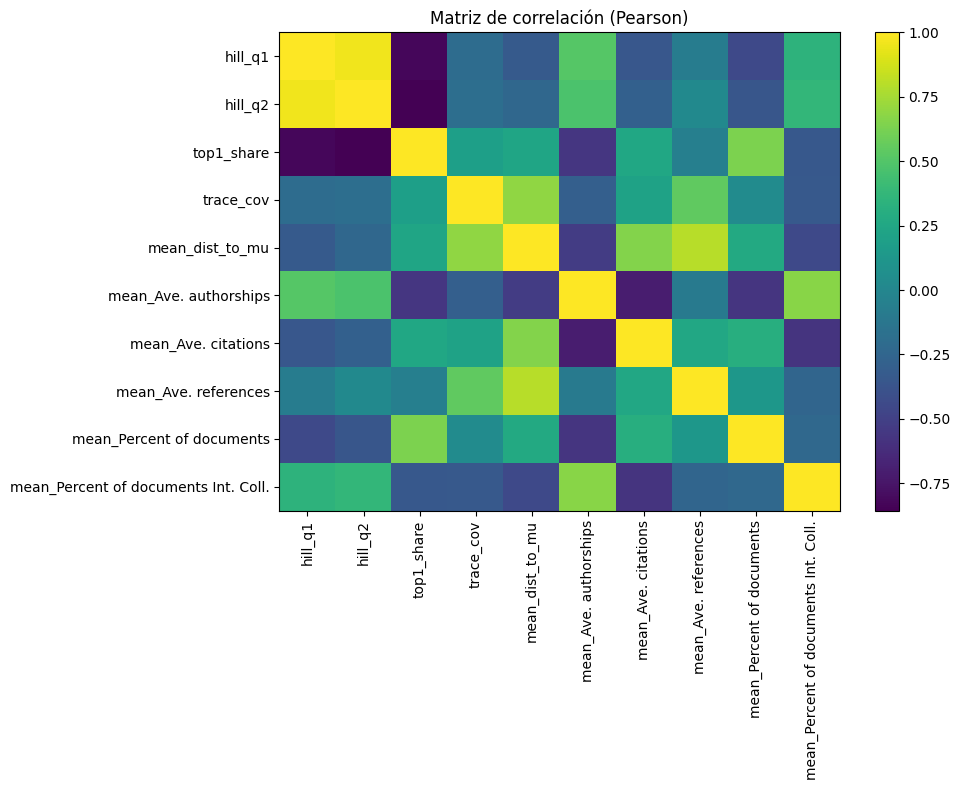

In [305]:
plot_corr_matrix(corr_pearson, "Matriz de correlación (Pearson)")

In [306]:
def _clean_1d(x: np.ndarray):
    """Limpia NaN/Inf y deja solo finitos."""
    x = np.asarray(x, dtype=float).reshape(-1) #hacce la matriz sea plana, una sola fila
    x = x[np.isfinite(x)]
    return x

def global_quantile_edges(values_1d: np.ndarray, probs: list):
    """
    Calcula umbrales globales por cuantiles.
    Regresa array de edges
    Maneja casos degenerate (muchos valores iguales).


    """
    v = _clean_1d(values_1d)
    if v.size == 0:
        return None

    edges = np.quantile(v, probs)

    # Esto es para eliminar secciones repetidas,  por ejemplo si el 80% de  los papers tiene
    #0 citas  entonces la  lista de cortes sería [0,0,5], por lo que lo reducimos a [0,5]
    edges_unique = np.unique(edges)
    if edges_unique.size < edges.size:
        edges = edges_unique

    # Si al final no hay cortes (todo igual), regresamos None
    if edges.size == 0:
        return None

    return edges

In [307]:
def assign_bins(x: np.ndarray, edges: np.ndarray):
    """
    Asigna bins usando edges tipo cuantiles.
    Retorna bins en {0..K} donde K = len(edges) (si edges = [e1,e2,e3] => 4 bins).
    Regla:
      bin 0: x <= e1
      bin 1: e1 < x <= e2
      ...
      bin K: x > eK
    Si edges es None -> todo -1

    Regresa una lista del mismo tamaño del recibido, en lugar de valores,
    serán etiquetas ( a la cual pertenecen: Q1,Q2, Q3 o Q4)
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    bins = np.full(x.shape, -1, dtype=int)

    if edges is None:
        return bins

    # Para NaN/Inf dejamos -1
    mask = np.isfinite(x)
    xf = x[mask]

    # np.searchsorted con side='right' implementa (<= edge) correctamente
    # regresa [0..len(edges)]
    b = np.searchsorted(edges, xf, side="right")
    bins[mask] = b
    return bins

'''

Unweighted: cada nodo aporta un valor de uno sin importar su perfil bibliometrico
Weighted: ponderado en base a la cantidad de documentos.

Por ejemplo para unweighted si tengo 5 papers en Q1 y 5 en Q4, Q1 es el 50%
para weighted si tengo 5 papers en Q1 pero aportan mas, entonces Q1 es el 90%
'''

def shares_from_bins(bins: np.ndarray, weights: np.ndarray, n_bins: int):
    """
    Calcula proporciones por bin (0..n_bins-1).
    bins: array de enteros (puede traer -1 para missing)
    weights: pesos por alter (si None: usa 1s)
    """
    bins = np.asarray(bins, dtype=int)
    valid = bins >= 0
    bins_v = bins[valid]

    if weights is None:
        w = np.ones(bins_v.shape[0], dtype=float)
    else:
        w_all = np.asarray(weights, dtype=float).reshape(-1)
        w_all = np.where(np.isfinite(w_all), w_all, 0.0)
        w_all = np.where(w_all < 0, 0.0, w_all)
        w = w_all[valid]

    total = w.sum()
    if total <= 0:
        return np.array([np.nan]*n_bins, dtype=float)

    out = np.zeros(n_bins, dtype=float)
    for k in range(n_bins):
        out[k] = w[bins_v == k].sum() / total
    return out

In [308]:
DOCS_COL = "Documents,"  # masa para ponderar
CAT_SPECS = {
    "Ave. citations": {
        "n_bins": 4,
        "probs": [0.25, 0.50, 0.75],
        "labels": ["baja", "media", "media_alta", "alta"]
    },
    "Ave. references": {
        "n_bins": 4,
        "probs": [0.25, 0.50, 0.75],
        "labels": ["baja", "media", "media_alta", "alta"]
    },
    "Percent of documents Int. Coll.": {
        "n_bins": 4,
        "probs": [0.25, 0.50, 0.75],
        "labels": ["baja", "media", "media_alta", "alta"]
    },
    "Ave. authorships": {
        "n_bins": 3,
        "probs": [1/3, 2/3],
        "labels": ["baja", "media", "alta"]
    }
}

In [309]:
feature_names = [k for (_, k) in FEATURES]
idx_docs = feature_names.index(DOCS_COL) if DOCS_COL in feature_names else None #Solo es para ubicar la posicion del feature "Documents,"


In [310]:
# Construir umbrales globales

global_edges = {}

for feat, spec in CAT_SPECS.items():
    if feat not in feature_names:
        print(f"[WARN] Feature no encontrado en feature_names: {feat}. Se omitirá.")
        global_edges[feat] = None
        continue

    j = feature_names.index(feat) #indice del feature en la matriz X, si av citations es columna 3 entonces j=3

    # juntar valores de todos los años (alters)
    all_vals = [] #lista de listas, cada lista tiene los valores de la columna recibida (el feature)
    for y in sorted(snapshots.keys()):
        X = snapshots[y]["X_alters"]
        if X.size == 0:
            continue
        col = X[:, j]
        all_vals.append(col)

    if len(all_vals) == 0:
        global_edges[feat] = None
        continue

    all_vals = np.concatenate(all_vals, axis=0) #Todos los valores de los alters del feature

    edges = global_quantile_edges(all_vals, spec["probs"])
    global_edges[feat] = edges

    # debug opcional
    if edges is None:
        print(f"[INFO] {feat}: edges=None (distribución degenerada o vacía).")
    else:
        print(f"[OK] {feat}: edges globales = {edges}")

[OK] Ave. citations: edges globales = [ 2.67  9.   22.  ]
[OK] Ave. references: edges globales = [31. 46. 73.]
[OK] Percent of documents Int. Coll.: edges globales = [ 0. 25.]
[OK] Ave. authorships: edges globales = [3.   4.18]


In [311]:
rows_cat = []

for year in sorted(snapshots.keys()):
    snap = snapshots[year]
    X = snap["X_alters"]

    if X.size == 0:
        continue

    # pesos para ponderar (Documents,)
    w_docs = None
    if idx_docs is not None:
        w_docs = X[:, idx_docs]

    row = {"year": year}

    for feat, spec in CAT_SPECS.items():
        if feat not in feature_names:
            continue

        j = feature_names.index(feat)
        edges = global_edges.get(feat)


        '''
        En lugar de [1 cita, 50 citas, 2 citas], ahora tenemos [0, 3, 0] (Bajo, Alto, Bajo)
        Se asigna el bin en base a estos valores.

        Ejemplo completo:

        si los edges globales son [2.0, 10.0, 20.0] las etiquetas son [bajo, medio, medio_alto, alto]
        Tenemos  3 alters: Causal Inference con 1 documento, Rock Mechanics con 1 documento y 
        Reservoir Operation con  8 documentos

        Assign_bins se encarga de asignar bins:
        Causal Inference ->  menor que 2.0 -> Bin 0
        Rock mechanics ->  menor que 2.0 -> Bin 0
        Reservoir Operation ->  mayor que 2.0 y menor que 10.0 -> Bin 1
        Bins -> [0,0,1]

        Share_from_bins Caso unweighted
        Total de alters: 3
        Bin 0: 2 alters 2/3 ->0.66 (66%)
        Bin 1: 1 alter 1/3 ->0.33 (99%)
        Bin 2: 0 alters -> 0.0
        Bin 3: 0 alters -> 0.0

        Share_from_bins Caso weighted
        Total de documents: 10
        Bin 0: 1+1=2 -> 2/10 -> 0.20(20%)
        Bin 1: 8 -> 8/10 -> 0.80(80%)
        Bin 2: 0 -> 0.0
        Bin 3: 0 -> 0.0

        Ultimo paso, guardar:
        unw_citations_bajo:0.66
        w_citations_bajo:0.20
        unw_citations_medio:0.33
        w_citations_medio:0.80
        el resto es 0.0

        Al final todos los weighted suman 1 y todos los unweighted suman 1
        '''
        bins = assign_bins(X[:, j], edges)

        # si edges colapsó (por ejemplo 1 edge en vez de 3), el número de bins reales cambia
        # Definimos n_bins_real = len(edges)+1 si edges existe, sino spec["n_bins"]
        if edges is None:
            n_bins_real = spec["n_bins"]
            labels = spec["labels"]
        else:
            n_bins_real = len(edges) + 1
            labels = spec["labels"][:n_bins_real] # si colapsó y hay menos bins que labels, ajustamos labels automáticamente
            '''
            edges = [2.67, 9, 22] → len=3
            n_bins_real = 4
            labels = ["baja","media","media_alta","alta"][:4]
            '''

        s_unw = shares_from_bins(bins, weights=None, n_bins=n_bins_real)
        s_w = shares_from_bins(bins, weights=w_docs, n_bins=n_bins_real)

        # Guardar columnas con nombres estables
        # share_unw_citations_baja, share_w_citations_alta, etc.
        safe_feat = feat.replace(" ", "_").replace(".", "").replace(",", "").replace("%", "pct")

        for k, lab in enumerate(labels):
            row[f"unw_{safe_feat}_{lab}"] = float(s_unw[k]) if np.isfinite(s_unw[k]) else np.nan
            row[f"wdocs_{safe_feat}_{lab}"] = float(s_w[k]) if np.isfinite(s_w[k]) else np.nan

    rows_cat.append(row)


df_cats = pd.DataFrame(rows_cat).sort_values("year").reset_index(drop=True)


In [312]:
# df_cats ya existe aquí:
# df_cats = pd.DataFrame(rows_cat).sort_values("year").reset_index(drop=True)

out_path_cats = f"./Output/categorias_{LEVEL}_detallado.csv"
df_cats.to_csv(out_path_cats, index=False)
print(f"[OK] Guardado categorías: {out_path_cats}")


[OK] Guardado categorías: ./Output/categorias_meso_detallado.csv


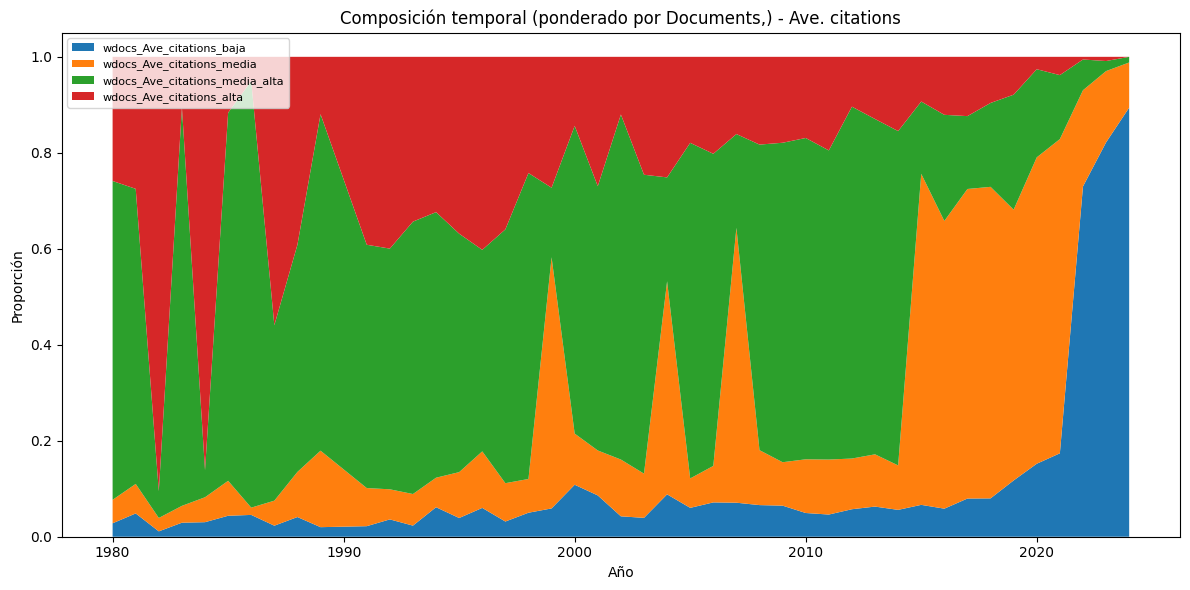

In [313]:
df_plot =df_cats
def plot_stack_shares(df, year_col, cols, title):
    """
    Plot de proporciones (stacked area) para ver composición temporal.
    cols: lista de columnas que suman aprox 1.
    """
    dfp = df[[year_col] + cols].copy().sort_values(year_col)
    plt.figure(figsize=(12, 6))
    plt.stackplot(dfp[year_col], [dfp[c].fillna(0.0) for c in cols], labels=cols)
    plt.title(title)
    plt.xlabel("Año")
    plt.ylabel("Proporción")
    plt.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

#feat = "Ave._authorships"
#feat = "Percent of documents Int. Coll."
feat = "Ave._citations"
#feat = "Ave._references"
safe_cit = feat.replace(" ", "_").replace(".", "").replace(",", "").replace("%", "pct")
cols_cit_w = [c for c in df_cats.columns if c.startswith(f"wdocs_{safe_cit}_")]
if len(cols_cit_w) > 0:
    plot_stack_shares(
        df_plot,
        year_col="year",
        cols=cols_cit_w,
        title="Composición temporal (ponderado por Documents,) - Ave. citations"
    )

In [314]:

df = pd.read_csv(f"./Output/categorias_{LEVEL}_detallado.csv")
def _norm_colname(c: str) -> str:
    c = str(c).strip()
    c = c.replace(" ", "_")
   # c = c.replace(",", "") 
    c = re.sub(r"__+", "_", c)
    return c

df.columns = [_norm_colname(c) for c in df.columns]


FEATURE_SPECS = {
    "Ave_citations": {
        "cats": ["baja", "media", "media_alta", "alta"]
    },
    "Ave_references": {
        "cats": ["baja", "media", "media_alta", "alta"]
    },
    "Ave_authorships": {
        "cats": ["baja", "media", "alta"]     # terciles
    },
    "Percent_of_documents_Int_Coll": {
        # este feature a veces queda en 3 bins (baja, media, media_alta) por edges=[0,25]
        # entonces aquí ponemos el set "máximo" y abajo el código ignora las que no existan
        "cats": ["baja", "media", "media_alta", "alta"]
    }
}

def find_dist_cols(df: pd.DataFrame, prefix: str, feature: str, cats: list):
    """
    Busca columnas {prefix}_{feature}_{cat} y devuelve dict cat->col solo si existen.

    {
    "baja": "unw_Ave_citations_baja",
    "media": "unw_Ave_citations_media",
    ...
    }

    """
    out = {}
    for cat in cats:
        col = f"{prefix}_{feature}_{cat}"
        if col in df.columns:
            out[cat] = col
    return out

def dominant_label_from_cols(df: pd.DataFrame, cols_dict: dict):
    """
    cols_dict: {cat: colname}
    Devuelve Serie con etiqueta dominante por fila.
    Dada la distribución por categorías (proporciones), elegir la categoría dominante por fila (por año)
    """
    if len(cols_dict) < 2:
        return pd.Series([np.nan] * len(df), index=df.index)

    mat = df[list(cols_dict.values())].to_numpy(dtype=float)
    mat = np.where(np.isfinite(mat), mat, -np.inf)

    winners = np.argmax(mat, axis=1)
    cats_list = list(cols_dict.keys())

    # si toda la fila es -inf (todo NaN), devolver NaN
    out = []
    for r, k in enumerate(winners):
        if np.isfinite(mat[r, k]):
            out.append(cats_list[k])
        else:
            out.append(np.nan)
    return pd.Series(out, index=df.index)

def add_dominants(df: pd.DataFrame, feature_specs: dict):
    df_out = df.copy()

    for feature, spec in feature_specs.items():
        cats = spec["cats"]

        # unw
        cols_unw = find_dist_cols(df_out, "unw", feature, cats)
        df_out[f"dom_unw_{feature}"] = dominant_label_from_cols(df_out, cols_unw)

        # wdocs
        cols_w = find_dist_cols(df_out, "wdocs", feature, cats)
        df_out[f"dom_wdocs_{feature}"] = dominant_label_from_cols(df_out, cols_w)

    return df_out

In [315]:
df2 = add_dominants(df, FEATURE_SPECS)

for feature in FEATURE_SPECS.keys():
    df2[f"unw_label_{feature}"] = df2[f"dom_unw_{feature}"]
    df2[f"wdocs_label_{feature}"] = df2[f"dom_wdocs_{feature}"]

label_cols = ["year"]
for feature in FEATURE_SPECS.keys():
    label_cols += [f"unw_label_{feature}", f"wdocs_label_{feature}"]

df_summary = df2[label_cols].sort_values("year").reset_index(drop=True)


In [316]:
print(df_summary.head())

   year unw_label_Ave_citations wdocs_label_Ave_citations  \
0  1980                    alta                media_alta   
1  1981                    alta                media_alta   
2  1982                    alta                      alta   
3  1983              media_alta                media_alta   
4  1984                    alta                      alta   

  unw_label_Ave_references wdocs_label_Ave_references  \
0                     alta                      media   
1                    media                      media   
2                     alta                      media   
3                    media                      media   
4                     alta                      media   

  unw_label_Ave_authorships wdocs_label_Ave_authorships  \
0                      baja                        baja   
1                      baja                       media   
2                      baja                       media   
3                      baja                        baj

In [317]:
out_dir = "./Output"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, f"categorias_{LEVEL}_simplificado.csv")
df_summary.to_csv(out_path, index=False, encoding="utf-8")

print(f"[OK] Guardado: {out_path}")

[OK] Guardado: ./Output/categorias_meso_simplificado.csv
